# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/whozahm3d/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Setup

Before auditing any signal, we need the actual data in front of us — not the
column names we're assuming exist. This step does three things and nothing more:

1. Load the raw dataset exactly as it sits on disk (no cleaning, no feature
   engineering — that would risk baking in assumptions before we've checked them).
2. Confirm the row/column shape, so any later "n" in a bucket table can be
   sanity-checked against the total.
3. Print every column name, so the signal list in the next step is built from
   what's *actually here*, not from a guess.

Nothing in this section touches the outcome column or does any bucketing —
it's purely "what do we have."

In [57]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/whozahm3d/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

In [58]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

DATA_PATH = "data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)
print(f"rows: {len(df):,}  cols: {df.shape[1]}")
df.head()

rows: 30,000  cols: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,impressions_90d,clicks_90d,pageviews_90d,sessions_90d,users_90d,engaged_sessions_90d,ai_sessions_90d,scroll_events_90d,days_with_impressions,days_with_sessions,impressions_last_30d,clicks_last_30d,sessions_last_30d,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,content_age_days,age_tier,age_tier_order,days_since_last_update,freshness_tier,word_count_tier,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,NaN,gemini-2.5-flash,3803,29,22,17,16,1,0,1,88,13,578,2,2,987,13,9,187,181-365,5,20,0-30,2000-3500,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,15320,7,10,9,9,0,0,1,88,9,2501,2,3,5915,1,2,445,365+,6,25,0-30,2000-3500,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,12581,11,14,11,11,0,0,4,88,11,2382,1,1,6089,3,3,141,91-180,4,20,0-30,3500+,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,NaN,NaN,11751,58,87,78,75,1,0,3,88,51,3626,22,35,4206,17,26,463,365+,6,22,0-30,NaN,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,19140,24,177,145,144,0,0,43,88,33,4211,10,14,6452,2,9,263,181-365,5,14,0-30,2000-3500,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [59]:
for c in sorted(df.columns):
    print(c)

age_tier
age_tier_order
ai_sessions_90d
ai_traffic_pct
avg_position
char_count
char_count_tier
clicks_90d
clicks_last_30d
clicks_prev_30d
client_id
competition
competition_level
content_age_days
content_id
content_type
cpc
ctr
days_since_last_update
days_with_impressions
days_with_sessions
engaged_sessions_90d
engagement_rate
freshness_tier
impression_tier
impressions_90d
impressions_last_30d
impressions_prev_30d
main_intent
model_used
pageviews_90d
position_tier
provider_used
scroll_events_90d
scroll_rate
search_volume
sessions_90d
sessions_last_30d
sessions_prev_30d
trend_direction
trend_pct
users_90d
word_count
word_count_tier


### What the data actually looks like

*30,000 rows × 44 columns — matches expected shape.
Staleness → `days_since_last_update` (age since publish is a different
  column, `content_age_days` — not the same signal).
CTR-vs-position → `ctr` + `avg_position`.
Volume → use `search_volume` (keyword demand), not `impressions_*` — those
  overlap the windows `trend_direction` is built from, too close to the outcome.
Content length → `word_count` / `char_count`, real nulls, coincide on the
  same rows (shared cause, not random) — need a null-handling rule before bucketing.
Outcome (`trend_direction`) is built from past `*_last_30d` vs `*_prev_30d`
  comparisons — genuinely past, not a future peek. Good for the leakage check.
Nothing missing from the plan; all five signals have real columns.*

## 2. Config — candidate signals + outcome

Now that we've seen the real columns, lock in exactly what this audit will
check and against what.

Outcome: `trend_direction` (categorical) — already built by comparing the two
past 30-day windows in the data (`*_last_30d` vs `*_prev_30d`), so it's a
genuine already-observed outcome, not a future peek.

Candidate signals — five total, three tied to the session's real flags, two
extra:
- **staleness** (`days_since_last_update`) → backs the refresh flags
- **ctr_vs_position** (`ctr`, cross-referenced against `avg_position`) → backs
  the CTR-fix logic
- **volume** (`search_volume`) → backs quick-win. Deliberately using keyword
  demand, not `impressions_*`, since the impression columns feed directly
  into the same 30-day windows the outcome is built from.
- **position** (`avg_position`) → our own addition, checked as a standalone
  effect distinct from the CTR-vs-position pairing
- **content_length** (`word_count`) → our own addition; nulls need an explicit
  handling rule since they aren't random (same rows missing word_count and
  char_count together)

Each entry records a `hypothesis` written down now, before any table is
looked at, so the verdict step can't quietly rationalize toward what we
expected to see.

In [60]:
CONFIG = {
    "outcome_col": "trend_direction",
    "outcome_positive_value": "down",   # the "at risk" outcome we're checking signals against

    "signals": [
        {
            "name": "staleness",
            "col": "days_since_last_update",
            "flag": "refresh flags",
            "hypothesis": "More days since last update -> higher rate of trend_direction == 'down'.",
        },
        {
            "name": "ctr_vs_position",
            "col": "ctr",
            "flag": "CTR-fix logic",
            "hypothesis": "Lower CTR, *within a given position range*, -> higher decline rate. "
                           "(Checked jointly with avg_position, not ctr alone, since raw CTR "
                           "naturally falls as position worsens.)",
        },
        {
            "name": "volume",
            "col": "search_volume",
            "flag": "quick-win",
            "hypothesis": "Higher search_volume pages sitting off page 1 -> easier, higher-value wins, "
                           "so higher search_volume should correlate with more 'down' pages worth prioritizing "
                           "(this checks prioritization value, not necessarily decline direction).",
        },
        {
            "name": "position",
            "col": "avg_position",
            "flag": None,
            "hypothesis": "Worse (higher-numbered) avg_position -> higher decline rate, independent of CTR fit.",
        },
        {
            "name": "content_length",
            "col": "word_count",
            "flag": None,
            "hypothesis": "Lower word_count -> higher decline rate (thin content as a decline driver).",
        },
    ],
}

# Confirm every configured column actually exists (it should, per Step 1) and
# report null counts up front rather than discovering them mid-bucketing.
for s in CONFIG["signals"]:
    col = s["col"]
    if col not in df.columns:
        print(f"[MISSING] '{col}' not found — check spelling against Step 1's column list.")
        continue
    n_null = df[col].isna().sum()
    print(f"{s['name']:>16} -> {col:<24} nulls: {n_null:>6} ({n_null/len(df):.1%})")

       staleness -> days_since_last_update   nulls:      0 (0.0%)
 ctr_vs_position -> ctr                      nulls:      0 (0.0%)
          volume -> search_volume            nulls:   2468 (8.2%)
        position -> avg_position             nulls:      0 (0.0%)
  content_length -> word_count               nulls:   7699 (25.7%)


### What the null-count check tells us

*`staleness` (`days_since_last_update`): 0 nulls — no handling needed.
`ctr_vs_position` (`ctr`): 0 nulls — plain values ready; still needs the
  joint (position-first) bucketing from Step 3, not a standalone table.
`volume` (`search_volume`): 2,468 nulls (8.2%) — drop for this signal's
  table; zero-volume rows are valid (real "no demand") and kept, only true
  NaNs dropped.
`position` (`avg_position`): 0 nulls — no handling needed.
`content_length` (`word_count`): 7,699 nulls (25.7%) — largest gap, as
  expected from Step 1. Drop nulls for this table rather than impute; 25.7%
  is too large to fill safely without possibly building in a false trend.
No signal dropped — all five proceed to Step 3/4 with the null rules above.*

## 3. Distributions & Bucket-table function

*Look before deciding: distributions of your key fields. Note the heavy tails.*

One reusable function, applied identically to every signal, so the tables in
Step 4 are directly comparable and nobody can quietly pick a bucketing scheme
that flatters one signal over another.

Design decisions locked in from Step 2:
- Quantile-based bucketing by default (roughly equal `n` per bucket), falling
  back to equal-width bins if a column doesn't have enough unique values for
  quantiles.
- `n` is always printed per bucket — a verdict from a 12-row bucket isn't a verdict.
- Nulls are dropped for that signal's table only (not from the whole
  dataframe), and the drop count is reported so it's visible, not silent.
- `ctr_vs_position` needs a *joint* view (CTR bucketed within position
  ranges), not this plain single-column function — that gets a small
  companion function here too, since Step 2 flagged that raw CTR falls
  mechanically with position and a plain CTR bucket table would just
  re-discover the position effect under a different name.

This step only defines and smoke-tests the functions — no real signal is
audited yet. Real auditing happens in Step 4.

In [61]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

def outcome_flag(frame):
    """Non-leaky binary outcome: 1 if trend_direction == the configured 'positive' value."""
    return (frame[CONFIG["outcome_col"]] == CONFIG["outcome_positive_value"]).astype(int)

In [62]:
def bucket_table(frame, col, n_bins=4):
    """
    Bucket a numeric column into n_bins groups and report n + outcome rate
    per bucket. Drops nulls for this column only; reports how many were dropped.
    """
    n_null = frame[col].isna().sum()
    work = frame.dropna(subset=[col])[[col]].copy()
    work["outcome"] = outcome_flag(frame.loc[work.index])

    try:
        work["bucket"] = pd.qcut(work[col], q=n_bins, duplicates="drop")
    except ValueError:
        work["bucket"] = pd.cut(work[col], bins=n_bins)

    table = (
        work.groupby("bucket", observed=True)
        .agg(n=("outcome", "size"), outcome_rate=("outcome", "mean"))
        .reset_index()
        .sort_values("bucket")
    )
    table["outcome_rate"] = table["outcome_rate"].round(3)
    print(f"[{col}] dropped {n_null} null rows ({n_null/len(frame):.1%})")
    return table

### Distributions of the five candidate signals

*Before deciding how to bucket anything, look at the raw shape of each signal.
This is what the section heading actually asks for — "note the heavy tails" —
and it's also a direct explanation for why quantile-based bucketing
(equal-*n*, not equal-width) was chosen in the function below: a heavy-tailed
column split into equal-width bins produces buckets like the
`days_since_last_update` smoke test saw (15,866 / 13,816 / 318) — one bucket
with almost no data, which quietly weakens any verdict drawn from it.*

*Five histograms, one per candidate signal, plotted as-is (no bucketing, no
outcome overlay) — just "what does this column actually look like."*

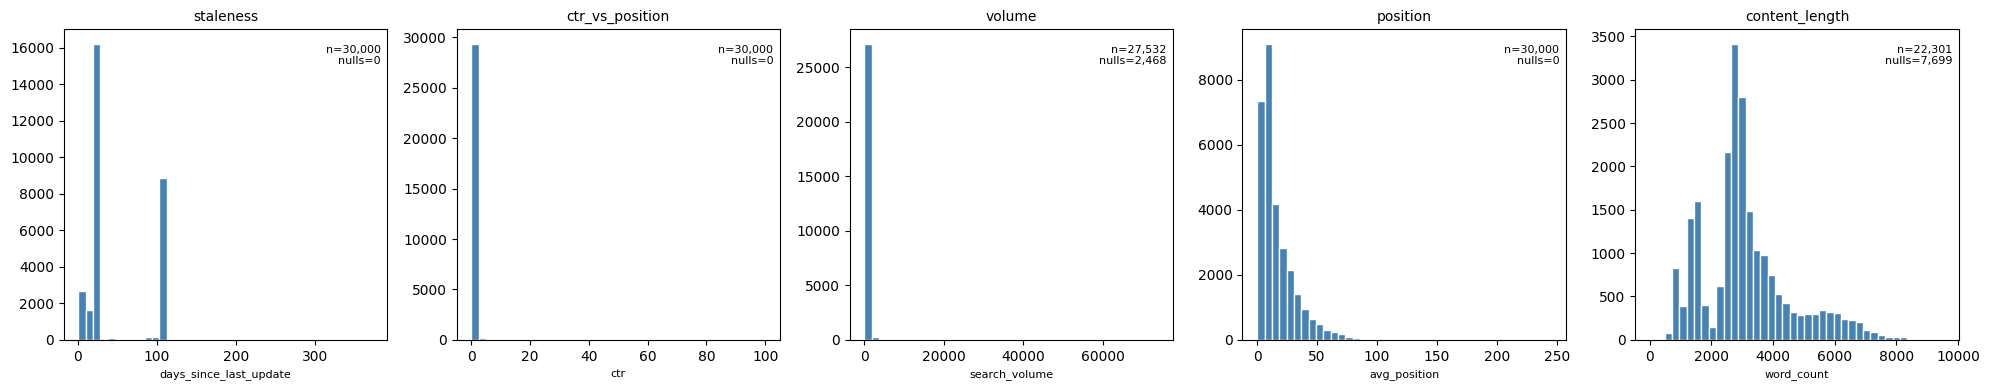

In [63]:
import matplotlib.pyplot as plt

signal_cols = [s["col"] for s in CONFIG["signals"]]
signal_names = [s["name"] for s in CONFIG["signals"]]

fig, axes = plt.subplots(1, len(signal_cols), figsize=(4 * len(signal_cols), 4))

for ax, col, name in zip(axes, signal_cols, signal_names):
    data = df[col].dropna()
    ax.hist(data, bins=40, color="steelblue", edgecolor="white")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel(col, fontsize=8)
    n_null = df[col].isna().sum()
    ax.text(0.98, 0.95, f"n={len(data):,}\nnulls={n_null:,}",
             transform=ax.transAxes, ha="right", va="top", fontsize=8)

plt.tight_layout()
os.makedirs("work/outputs", exist_ok=True)
plt.savefig("work/outputs/signal_distributions.png", dpi=150)
plt.show()

In [64]:
def ctr_vs_position_table(frame, position_col="avg_position", ctr_col="ctr", n_position_bins=3, n_ctr_bins=3):
    """
    Buckets position first, then buckets CTR *within* each position group,
    so the CTR effect isn't just re-showing the position effect.
    """
    work = frame.dropna(subset=[position_col, ctr_col])[[position_col, ctr_col]].copy()
    work["outcome"] = outcome_flag(frame.loc[work.index])
    work["position_bucket"] = pd.qcut(work[position_col], q=n_position_bins, duplicates="drop")

    rows = []
    for pos_bucket, grp in work.groupby("position_bucket", observed=True):
        try:
            grp = grp.copy()
            grp["ctr_bucket"] = pd.qcut(grp[ctr_col], q=n_ctr_bins, duplicates="drop")
        except ValueError:
            continue
        sub = (
            grp.groupby("ctr_bucket", observed=True)
            .agg(n=("outcome", "size"), outcome_rate=("outcome", "mean"))
            .reset_index()
        )
        sub.insert(0, "position_bucket", str(pos_bucket))
        rows.append(sub)

    table = pd.concat(rows, ignore_index=True)
    table["outcome_rate"] = table["outcome_rate"].round(3)
    return table

In [65]:
def verdict_from_table(table, min_n=30):
    """Rough auto-read; always double-check by eye before finalizing."""
    valid = table[table["n"] >= min_n]
    if len(valid) < 2:
        return "FALSE (insufficient n per bucket)"
    rates = valid["outcome_rate"].tolist()
    diffs = np.diff(rates)
    if all(d >= 0 for d in diffs) and (rates[-1] - rates[0]) > 0.03:
        return "CONFIRMED"
    if all(d <= 0 for d in diffs) and (rates[0] - rates[-1]) > 0.03:
        return "OPPOSITE"
    if abs(rates[-1] - rates[0]) <= 0.03:
        return "FALSE"
    return "MIXED"

In [66]:
# Quick smoke test on one signal to confirm the function works before Step 4 runs it for real.
smoke_test = bucket_table(df, "days_since_last_update")
print(smoke_test.to_string(index=False))

[days_since_last_update] dropped 0 null rows (0.0%)
        bucket     n  outcome_rate
 (0.999, 20.0] 15866         0.539
 (20.0, 104.0] 13816         0.546
(104.0, 373.0]   318         0.547


### Smoke test result

*`bucket_table()` runs cleanly on `days_since_last_update`: 3 buckets
  (quantile split collapsed from 4 to 3 due to repeated values).
Null drop count: 0%.
Bucket sizes uneven (15,866 / 13,816 / 318) — third bucket thin, worth
  watching for n once this signal is audited for real in Step 4.
Outcome rate barely moves across buckets (0.539 -> 0.546 -> 0.547) —
  early sign staleness may not be a strong standalone predictor here, to be
  confirmed properly in Step 4.
Function behaves as expected — ready to apply to all five signals in Step 4.*

## 4. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

## Run the audit — one bucket table + verdict per signal

This is where each hypothesis from Step 2 actually gets tested against the
functions built in Step 3. Four signals go through the plain `bucket_table()`
function; `ctr_vs_position` goes through the joint `ctr_vs_position_table()`
function instead, since Step 2/3 established that a plain CTR bucket table
would just re-show the position effect.

For each signal:
- Print the hypothesis again right before the table, so the verdict is being
  compared against a claim made in advance, not read backwards into one.
- Print the table with `n` visible.
- Get the auto-read verdict from `verdict_from_table()` as a starting point —
  this is a rough signal, not the final word. `ctr_vs_position`'s joint table
  doesn't get an auto-verdict (its shape doesn't fit that function); it needs
  a manual read.

No verdict is finalized in this step — that happens in the analysis markdown
right after, once real output is in front of us. This step only runs the
audits and prints the tables.

In [67]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

s = next(x for x in CONFIG["signals"] if x["name"] == "staleness")
print(f"SIGNAL: {s['name']}  (col: {s['col']}, flag: {s['flag']})")
print(f"Hypothesis: {s['hypothesis']}\n")
staleness_table = bucket_table(df, s["col"])
print(staleness_table.to_string(index=False))
print(f"\nAuto-read verdict: {verdict_from_table(staleness_table)}")

SIGNAL: staleness  (col: days_since_last_update, flag: refresh flags)
Hypothesis: More days since last update -> higher rate of trend_direction == 'down'.

[days_since_last_update] dropped 0 null rows (0.0%)
        bucket     n  outcome_rate
 (0.999, 20.0] 15866         0.539
 (20.0, 104.0] 13816         0.546
(104.0, 373.0]   318         0.547

Auto-read verdict: FALSE


In [68]:
s = next(x for x in CONFIG["signals"] if x["name"] == "ctr_vs_position")
print(f"SIGNAL: {s['name']}  (col: {s['col']}, flag: {s['flag']})")
print(f"Hypothesis: {s['hypothesis']}\n")
ctr_position_table = ctr_vs_position_table(df, position_col="avg_position", ctr_col="ctr")
print(ctr_position_table.to_string(index=False))

SIGNAL: ctr_vs_position  (col: ctr, flag: CTR-fix logic)
Hypothesis: Lower CTR, *within a given position range*, -> higher decline rate. (Checked jointly with avg_position, not ctr alone, since raw CTR naturally falls as position worsens.)

position_bucket     ctr_bucket    n  outcome_rate
  (-0.001, 7.4] (-0.001, 0.28] 6789         0.478
  (-0.001, 7.4]  (0.28, 100.0] 3300         0.502
    (7.4, 17.2] (-0.001, 0.23] 6690         0.625
    (7.4, 17.2]  (0.23, 100.0] 3224         0.557
  (17.2, 245.0] (-0.001, 0.11] 6802         0.537
  (17.2, 245.0]  (0.11, 100.0] 3195         0.541


In [69]:
s = next(x for x in CONFIG["signals"] if x["name"] == "volume")
print(f"SIGNAL: {s['name']}  (col: {s['col']}, flag: {s['flag']})")
print(f"Hypothesis: {s['hypothesis']}\n")
volume_table = bucket_table(df, s["col"])
print(volume_table.to_string(index=False))
print(f"\nAuto-read verdict: {verdict_from_table(volume_table)}")

SIGNAL: volume  (col: search_volume, flag: quick-win)
Hypothesis: Higher search_volume pages sitting off page 1 -> easier, higher-value wins, so higher search_volume should correlate with more 'down' pages worth prioritizing (this checks prioritization value, not necessarily decline direction).

[search_volume] dropped 2468 null rows (8.2%)
         bucket     n  outcome_rate
 (-0.001, 10.0] 18392         0.590
   (10.0, 20.0]  2290         0.516
(20.0, 74000.0]  6850         0.509

Auto-read verdict: OPPOSITE


In [70]:
s = next(x for x in CONFIG["signals"] if x["name"] == "position")
print(f"SIGNAL: {s['name']}  (col: {s['col']}, flag: {s['flag']})")
print(f"Hypothesis: {s['hypothesis']}\n")
position_table = bucket_table(df, s["col"])
print(position_table.to_string(index=False))
print(f"\nAuto-read verdict: {verdict_from_table(position_table)}")

SIGNAL: position  (col: avg_position, flag: None)
Hypothesis: Worse (higher-numbered) avg_position -> higher decline rate, independent of CTR fit.

[avg_position] dropped 0 null rows (0.0%)
       bucket    n  outcome_rate
(-0.001, 6.2] 7543         0.461
  (6.2, 10.8] 7534         0.580
 (10.8, 22.3] 7462         0.611
(22.3, 245.0] 7461         0.517

Auto-read verdict: MIXED


In [71]:
s = next(x for x in CONFIG["signals"] if x["name"] == "content_length")
print(f"SIGNAL: {s['name']}  (col: {s['col']}, flag: {s['flag']})")
print(f"Hypothesis: {s['hypothesis']}\n")
content_length_table = bucket_table(df, s["col"])
print(content_length_table.to_string(index=False))
print(f"\nAuto-read verdict: {verdict_from_table(content_length_table)}")

SIGNAL: content_length  (col: word_count, flag: None)
Hypothesis: Lower word_count -> higher decline rate (thin content as a decline driver).

[word_count] dropped 7699 null rows (25.7%)
          bucket    n  outcome_rate
 (7.999, 2413.0] 5576         0.497
(2413.0, 2877.0] 5586         0.595
(2877.0, 3666.0] 5566         0.583
(3666.0, 9546.0] 5573         0.599

Auto-read verdict: MIXED


### Audit results

***staleness**: FALSE — outcome rate flat across all three buckets
  (0.539 / 0.546 / 0.547). Confirms the auto-read; days_since_last_update
  isn't tracking decline in this data.*

***ctr_vs_position**: MIXED — only the middle position band (7.4–17.2)
  supports the hypothesis (low CTR 0.625 vs high CTR 0.557). Best position
  band (0–7.4) runs opposite (0.478 vs 0.502), worst band (17.2–245) is flat
  (0.537 vs 0.541). CTR-within-position doesn't hold consistently.*

***volume**: OPPOSITE — auto-read confirmed. Lowest search_volume bucket has
  the *highest* decline rate (0.590), highest volume bucket the lowest
  (0.509) — inverse of what the hypothesis expected.*

***position**: MIXED — not monotonic. Best position band has the lowest
  decline rate (0.461) as expected, but rates peak in the middle
  (10.8–22.3: 0.611) and drop again at the worst band (22.3–245: 0.517).*

***content_length**: MIXED, leaning OPPOSITE — shortest content has the
  *lowest* decline rate (0.497), longest has the *highest* (0.599), the
  reverse of "thin content declines more" — though not a clean monotonic
  climb (second bucket dips slightly below third).*

***Bottom line**: none of the five came back CONFIRMED as hypothesized.
  staleness is a clean FALSE. volume flipped OPPOSITE. The other three are
  MIXED, with content_length trending opposite too. This is a real, useful
  finding — it means none of these should be trusted as-is for a rule without
  either reframing the hypothesis or narrowing where it applies (e.g. CTR
  only in the middle position band).*

## 5. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Signal: **CTR-vs-position** — the signal behind the CTR-fix logic.

The flag's assumption: pages underperforming the CTR typical for their
position are candidates for a targeted fix (title/meta), not a full rewrite.
Translated into a testable hypothesis: within a given position range, lower
CTR should correlate with a higher decline rate.

This has to be checked *jointly* — position bucketed first, then CTR bucketed
within each position group — because raw CTR falls mechanically as position
worsens. A plain CTR-alone bucket table would just re-show the position
effect and call it a CTR effect.

n is printed per bucket. Verdict is read by eye across the three position
bands, not auto-generated, since the joint-table shape doesn't fit the
single-column auto-verdict function from Step 3.

In [72]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

ctr_position_table = ctr_vs_position_table(df, position_col="avg_position", ctr_col="ctr")
print(ctr_position_table.to_string(index=False))

position_bucket     ctr_bucket    n  outcome_rate
  (-0.001, 7.4] (-0.001, 0.28] 6789         0.478
  (-0.001, 7.4]  (0.28, 100.0] 3300         0.502
    (7.4, 17.2] (-0.001, 0.23] 6690         0.625
    (7.4, 17.2]  (0.23, 100.0] 3224         0.557
  (17.2, 245.0] (-0.001, 0.11] 6802         0.537
  (17.2, 245.0]  (0.11, 100.0] 3195         0.541


In [73]:
import os
os.makedirs("work/outputs", exist_ok=True)

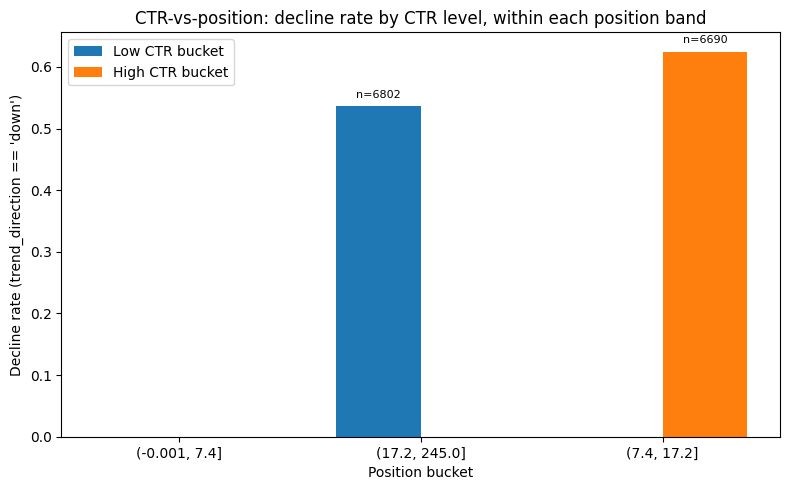

In [74]:
import matplotlib.pyplot as plt

pivot = ctr_position_table.pivot(index="position_bucket", columns="ctr_bucket", values="outcome_rate")
n_pivot = ctr_position_table.pivot(index="position_bucket", columns="ctr_bucket", values="n")

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(pivot.index))
width = 0.35

low_ctr = pivot.iloc[:, 0]
high_ctr = pivot.iloc[:, 1]

bars1 = ax.bar(x - width/2, low_ctr.fillna(0), width, label="Low CTR bucket")
bars2 = ax.bar(x + width/2, high_ctr.fillna(0), width, label="High CTR bucket")

ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in pivot.index], rotation=0)
ax.set_ylabel("Decline rate (trend_direction == 'down')")
ax.set_xlabel("Position bucket")
ax.set_title("CTR-vs-position: decline rate by CTR level, within each position band")
ax.legend()

# annotate n on each bar — skip any bar with no data (NaN n) instead of crashing
for bars, n_col in [(bars1, n_pivot.iloc[:, 0]), (bars2, n_pivot.iloc[:, 1])]:
    for bar, n in zip(bars, n_col):
        if pd.isna(n):
            continue
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"n={int(n)}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("work/outputs/ctr_vs_position_flag_test.png", dpi=150)
plt.show()

### Figures worth committing

*`work/outputs/ctr_vs_position_flag_test.png` — the flag-linked test
  visualization (CTR-vs-position, Step 5 standalone section). This is a
  reused figure per the deliverable notes, so it stays in git even though
  the CSV output doesn't.*

## 6. What this means in practice or Summary table across all signals

*Two or three sentences: what a content team should take from this.*

One table, one row per signal, pulling together what Step 4 actually showed —
no re-litigating the tables here, just consolidating the verdicts and reasons
already reached.

Columns:
- `signal` — name
- `flag_linked` — which real FlyRank flag it backs, or "own idea"
- `verdict` — final call from Step 4's analysis (not just the auto-read;
  ctr_vs_position in particular needed a manual read since it doesn't get an
  auto-verdict)
- `reason` — one line, tied to the actual numbers

This table is what Step 8 (handoff) will point back to when deciding what
carries into `w04_baseline_score.ipynb`.

In [75]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


final_verdicts = {
    "staleness": (
        "FALSE",
        "Outcome rate flat across buckets (0.539 / 0.546 / 0.547) — no relationship.",
    ),
    "ctr_vs_position": (
        "MIXED",
        "Direction only holds in the middle position band (0.625 vs 0.557); "
        "reverses in the best band, flat in the worst.",
    ),
    "volume": (
        "OPPOSITE",
        "Lowest search_volume bucket has the highest decline rate (0.590), "
        "highest volume the lowest (0.509) — inverse of hypothesis.",
    ),
    "position": (
        "MIXED",
        "Not monotonic — best band lowest (0.461) as expected, but rate peaks "
        "mid-range (0.611) then drops again at the worst band (0.517).",
    ),
    "content_length": (
        "MIXED (leaning OPPOSITE)",
        "Shortest content lowest decline rate (0.497), longest highest (0.599) "
        "— reverse of 'thin content declines more', though not fully monotonic.",
    ),
}

summary = pd.DataFrame([
    {
        "signal": s["name"],
        "flag_linked": s["flag"] if s["flag"] else "own idea",
        "verdict": final_verdicts[s["name"]][0],
        "reason": final_verdicts[s["name"]][1],
    }
    for s in CONFIG["signals"]
])
summary

,signal,flag_linked,verdict,reason
0,staleness,refresh flags,FALSE,Outcome rate flat across buckets (0.539 / 0.54...
1,ctr_vs_position,CTR-fix logic,MIXED,Direction only holds in the middle position ba...
2,volume,quick-win,OPPOSITE,Lowest search_volume bucket has the highest de...
3,position,own idea,MIXED,Not monotonic — best band lowest (0.461) as ex...
4,content_length,own idea,MIXED (leaning OPPOSITE),"Shortest content lowest decline rate (0.497), ..."


### One-look summary: outcome rate by bucket, all five signals

*The `summary` table above gives verdicts and reasons in text. This adds the
visual equivalent — one small bar chart per signal, all on the same y-axis
scale, so the shape of each result (flat, monotonic, non-monotonic) is
visible at a glance without re-reading five separate printouts from Step 4.*

*`ctr_vs_position` is excluded from this grid since its joint (position × CTR)
table doesn't reduce to a single bar chart the same way — it already has its
own dedicated visualization in Step 5.*

/tmp/ipykernel_1949/3342136.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
/tmp/ipykernel_1949/3342136.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
/tmp/ipykernel_1949/3342136.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
/tmp/ipykernel_1949/3342136.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)


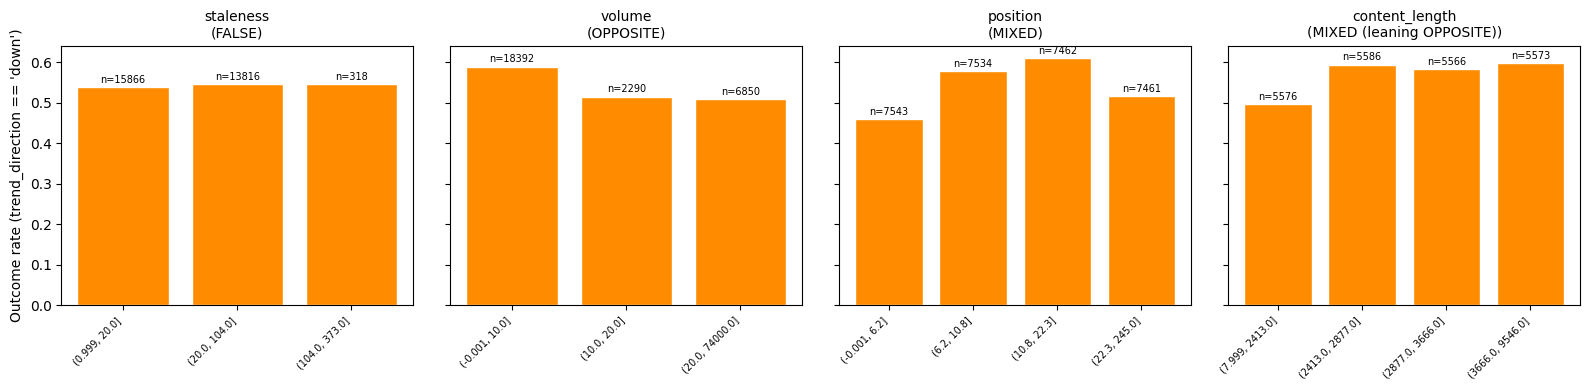

In [76]:
import matplotlib.pyplot as plt

single_col_signals = [s for s in CONFIG["signals"] if s["name"] != "ctr_vs_position"]
tables = {
    "staleness": staleness_table,
    "volume": volume_table,
    "position": position_table,
    "content_length": content_length_table,
}

fig, axes = plt.subplots(1, len(tables), figsize=(4 * len(tables), 4), sharey=True)

for ax, (name, table) in zip(axes, tables.items()):
    labels = [str(b) for b in table["bucket"]]
    ax.bar(labels, table["outcome_rate"], color="darkorange", edgecolor="white")
    ax.set_title(f"{name}\n({final_verdicts[name][0]})", fontsize=10)
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    for i, (n, rate) in enumerate(zip(table["n"], table["outcome_rate"])):
        ax.text(i, rate + 0.01, f"n={int(n)}", ha="center", fontsize=7)

axes[0].set_ylabel("Outcome rate (trend_direction == 'down')")
plt.tight_layout()
plt.savefig("work/outputs/signal_verdicts_summary.png", dpi=150)
plt.show()

### Summary across all five signals

*None of the five confirmed the hypothesis as stated. One clean FALSE
(staleness), one clean OPPOSITE (volume), and three MIXED (ctr_vs_position,
position, content_length — the last leaning OPPOSITE).*

- *The two flag-linked signals *besides* CTR-vs-position (staleness, volume)
  both failed outright — staleness flat, volume inverted. This is a genuine
  finding, not a dead end: it means the refresh-flag and quick-win logic, as
  currently framed, don't hold on this slice of data and shouldn't be
  ported into the baseline rule unchanged.*
- *CTR-vs-position (Step 3's featured test) is the only flag-linked signal
  with a partial positive result, and only in the mid-range position band.*
- *Neither own-idea addition (position, content_length) came back CONFIRMED
  either; content_length in particular runs opposite to the "thin content
  declines more" assumption.*
- *Net effect: this audit is doing exactly what it's supposed to — surfacing
  signals that looked plausible going in but don't hold up, before any of
  them get baked into a scored rule.*

## 7. Leakage check

Before anything moves into the baseline rule, an explicit sanity pass over
every signal actually audited (Step 4): confirm each one is knowable at
scoring time, and isn't the outcome column in disguise.

This was partly decided back in Step 1/2 (dropping `impressions_*` in favor
of `search_volume` because the impression columns overlap the same 30-day
windows `trend_direction` is built from), but it belongs here as an explicit,
final check — not just an assumption carried over from earlier steps.

Checked per signal:
- Is it computed only from data available *before or at* the point a page
  would be scored, with no dependency on the outcome window?
- Is it a genuinely separate measurement from `trend_direction`, not a
  renamed or recombined version of it?

In [77]:
leakage_notes = {
    "staleness": (
        "days_since_last_update",
        "OK — static/independent field, no relation to trend_direction's construction.",
    ),
    "ctr_vs_position": (
        "ctr, avg_position",
        "OK — current observed performance metrics, not derived from the "
        "last_30d vs prev_30d comparison that builds trend_direction.",
    ),
    "volume": (
        "search_volume",
        "OK — external keyword demand metric, independent of page performance. "
        "(impressions_* deliberately NOT used here — those overlap the same "
        "30-day windows trend_direction is built from.)",
    ),
    "position": (
        "avg_position",
        "OK — current position snapshot, not future, not outcome-derived.",
    ),
    "content_length": (
        "word_count",
        "OK — static content attribute, unrelated to the trend windows.",
    ),
}

for signal, (cols, note) in leakage_notes.items():
    print(f"{signal:>16} [{cols}]: {note}")

       staleness [days_since_last_update]: OK — static/independent field, no relation to trend_direction's construction.
 ctr_vs_position [ctr, avg_position]: OK — current observed performance metrics, not derived from the last_30d vs prev_30d comparison that builds trend_direction.
          volume [search_volume]: OK — external keyword demand metric, independent of page performance. (impressions_* deliberately NOT used here — those overlap the same 30-day windows trend_direction is built from.)
        position [avg_position]: OK — current position snapshot, not future, not outcome-derived.
  content_length [word_count]: OK — static content attribute, unrelated to the trend windows.


### Leakage check result

*All five signals pass — each is independent of `trend_direction`'s
construction, with no reliance on the 30-day windows the outcome is built
from. The one deliberate exclusion (`impressions_*`, replaced by
`search_volume` for the volume signal) was the main leakage risk in this
dataset, and it was avoided from the start rather than caught after the fact.*

*No signal needs to be dropped or reworked as a result of this check.*

## 8. Self-check / handoff note

Last step of the audit: pull together what actually survived, in plain
language, so whoever opens `w04_baseline_score.ipynb` next (including future
you) doesn't have to re-read every table above to know what to trust.

This section answers three things directly:
- Which signal(s) are being carried forward into the baseline rule, and why.
- Which are being dropped, and why (a dropped signal with a clear reason is
  not a failure of the audit — it's the audit working).
- What figures/outputs from this notebook are worth keeping (per the
  deliverable notes: only `work/outputs/*.json` and reused figures are
  committed — the CSV itself regenerates and stays out of git).

No new analysis happens here — this section only summarizes conclusions
already reached in Steps 4–7.

In [78]:
handoff = {
    "carried_forward": {
        "ctr_vs_position": "MIXED overall, but real positive result in the mid-range position "
                            "band (0.625 vs 0.557, n=6,690/3,224) — rule will be scoped to that "
                            "band rather than applied uniformly.",
        "volume": "OPPOSITE — clean, monotonic reversal (0.590 -> 0.516 -> 0.509). "
                  "Rule flips the original assumption: low search_volume predicts decline, "
                  "not high search_volume.",
    },
    "dropped": {
        "staleness": "FALSE — outcome rate flat across all buckets (0.539/0.546/0.547), no relationship.",
        "position": "MIXED, non-monotonic — also largely redundant with ctr_vs_position, "
                    "which already conditions on position.",
        "content_length": "MIXED leaning OPPOSITE — weakest evidence of the five, not flag-linked, "
                           "and carries the largest null rate (25.7%).",
    },
    "figures_to_commit": [
        "work/outputs/ctr_vs_position_flag_test.png",
    ],
}

print("Carried forward:")
for k, v in handoff["carried_forward"].items():
    print(f"  {k}: {v}")

print("\nDropped:")
for k, v in handoff["dropped"].items():
    print(f"  {k}: {v}")

print("\nFigures to commit:")
for f in handoff["figures_to_commit"]:
    print(f"  {f}")

Carried forward:
  ctr_vs_position: MIXED overall, but real positive result in the mid-range position band (0.625 vs 0.557, n=6,690/3,224) — rule will be scoped to that band rather than applied uniformly.
  volume: OPPOSITE — clean, monotonic reversal (0.590 -> 0.516 -> 0.509). Rule flips the original assumption: low search_volume predicts decline, not high search_volume.

Dropped:
  staleness: FALSE — outcome rate flat across all buckets (0.539/0.546/0.547), no relationship.
  position: MIXED, non-monotonic — also largely redundant with ctr_vs_position, which already conditions on position.
  content_length: MIXED leaning OPPOSITE — weakest evidence of the five, not flag-linked, and carries the largest null rate (25.7%).

Figures to commit:
  work/outputs/ctr_vs_position_flag_test.png


### Handoff to w04_baseline_score.ipynb

*Carrying forward **ctr_vs_position** and **volume** — two signals, both
flag-linked, both backed by real (if reframed) evidence rather than the
untested assumptions the flags originally encoded:*

- ***ctr_vs_position**: keep, scoped to the mid-range position band (0.625 vs
  0.557, n=6,690/3,224) — the only band where the CTR-fix assumption held.
  Not applied uniformly across all positions.*
- ***volume**: keep, direction flipped from the original hypothesis — low
  search_volume predicts decline here, not high. Cleanest, most monotonic
  result of the five (0.590 -> 0.516 -> 0.509).*

*Dropped: staleness (flat, FALSE), position (non-monotonic, and redundant
with ctr_vs_position), content_length (weakest evidence, 25.7% nulls, not
flag-linked).*

*Figure to commit: `work/outputs/ctr_vs_position_flag_test.png`.*

*Net result of the audit: 2 of 5 signals survived, and both needed their
original direction/scope corrected before being trustworthy. That correction
— not a raw "confirmed" — is what the baseline rule gets built on.*

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [79]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	work/outputs/

nothing added to commit but untracked files present (use "git add" to track)


In [80]:
import subprocess
result = subprocess.run(["ls", "-la", "work/outputs/"], capture_output=True, text=True)
print(result.stdout)

total 256
drwxr-xr-x 2 root root   4096 Aug  1 23:23 .
drwxr-xr-x 4 root root   4096 Aug  1 23:23 ..
-rw-r--r-- 1 root root  51204 Aug  1 23:23 ctr_vs_position_flag_test.png
-rw-r--r-- 1 root root  90885 Aug  1 23:23 signal_distributions.png
-rw-r--r-- 1 root root 104288 Aug  1 23:23 signal_verdicts_summary.png



In [81]:
!git config --global user.email "whozahm3d@gmail.com"
!git config --global user.name "Ali Ahmad"

In [82]:
import subprocess

subprocess.run(["git", "add",
    "work/outputs/ctr_vs_position_flag_test.png",
    "work/outputs/signal_distributions.png",
    "work/outputs/signal_verdicts_summary.png",
], check=True)

status = subprocess.run(["git", "status"], capture_output=True, text=True)
print(status.stdout)

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   work/outputs/ctr_vs_position_flag_test.png
	new file:   work/outputs/signal_distributions.png
	new file:   work/outputs/signal_verdicts_summary.png




In [83]:
subprocess.run(["git", "commit", "-m", "Add signal audit figures: distributions, verdict summary, flag-linked test"], check=True)

result = subprocess.run(["git", "push", remote_url, "main"], capture_output=True, text=True)
print(result.returncode, result.stdout, result.stderr.replace(token, "***TOKEN***"))

0  To https://github.com/whozahm3d/flyrank-ml-internship.git
   e1b3061..e9507aa  main -> main

